In [42]:
import pandas as pd
import sys
import numpy as np
from matplotlib import pyplot as plt
from pandas import DataFrame
from matplotlib.colors import BoundaryNorm
from tabulate import tabulate

In [43]:
DATABASE_GOOD = "sqlite:///../data/track2_good.db"
DATABASE_BAD = "sqlite:///../data/track2_bad.db"
OUTPUT = '../data/output.txt'
MD = '../data/output.md'
PROMPTS = '../prompts/prompts.txt'
TRACK_2_SEGMENT_POINTS = [(610, 2485), (635, 2780), (525, 2720), (880, 2790)]
QUERY = """SELECT timestamp_utc AS timestamp, acceleration_x, acceleration_y, acceleration_z, yaw, position_x, position_y, position_z, speed, lap_number
FROM telemetry_samples
WHERE distance_traveled != 0
ORDER BY id"""

In [44]:
def preprocess(df):
    df['timestamp'] = pd.to_datetime(df["timestamp"], utc=True).astype("int64") // 10**6
    df['timestamp'] = (df['timestamp'] - min(df['timestamp'])) / 1000

    df['position_x'] = df['position_x'].astype(int)
    df['position_y'] = df['position_y'].astype(int)
    df['position_z'] = df['position_z'].astype(int)

    df['acceleration_x'] = df['acceleration_x'].astype(int)
    df['acceleration_y'] = df['acceleration_y'].astype(int)
    df['acceleration_z'] = df['acceleration_z'].astype(int)
    df['yaw'] = df['yaw'].round(decimals=2)
    df['speed'] = (df['speed'] * 3.6).astype(int)
    
    return df

# Preprocessing


In [45]:
df_fast = preprocess(pd.read_sql(QUERY,DATABASE_GOOD))
df_slow = preprocess(pd.read_sql(QUERY, DATABASE_BAD))
df_slow = df_slow.iloc[::int(19), :]

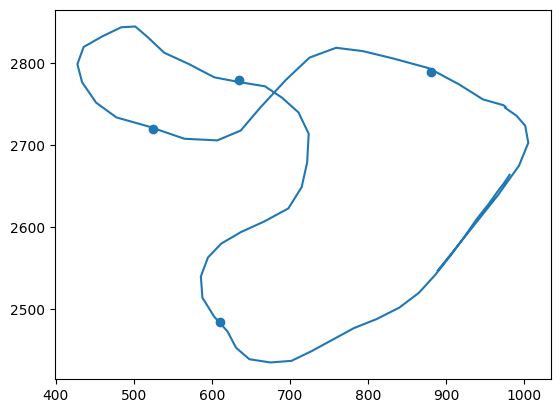

In [46]:
plt.plot(df_slow['position_x'], df_slow['position_z'])
plt.scatter([i[0] for i in TRACK_2_SEGMENT_POINTS], [i[1] for i in TRACK_2_SEGMENT_POINTS])
plt.show()

In [47]:
def get_index_nearest_position(point: tuple, positions_x: np.ndarray, positions_z: np.ndarray) -> int:
    smallest_distance = np.inf
    index = 0

    for i in range(positions_x.shape[0]):
        distance = np.sqrt(((point[0] - positions_x[i])**2 + (point[1] - positions_z[i])**2))
        if distance < smallest_distance:
            smallest_distance = distance
            index = i
    
    return index

def segment_labels(points: list, track: DataFrame):
    labels_all: list[int] = []

    for lap in track["lap_number"].unique():
        lap_df = track[track["lap_number"] == lap]
        n = len(lap_df)

        idxs = [
            int(get_index_nearest_position(
                p,
                lap_df["position_x"].to_numpy(),
                lap_df["position_z"].to_numpy()
            ))
            for p in points
        ]
        idxs = sorted({max(0, min(n, i)) for i in idxs})
        lap_labels = np.empty(n, dtype=int)
        start = 0
        seg = 0
        for cut in idxs:
            if cut <= start:
                continue
            lap_labels[start:cut] = seg
            seg += 1
            start = cut
        lap_labels[start:] = seg
        labels_all.extend(lap_labels.tolist())
    return labels_all

df_slow["segment"] = segment_labels(TRACK_2_SEGMENT_POINTS, df_slow)

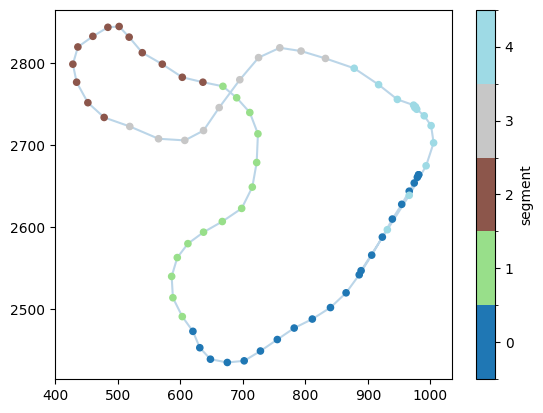

In [48]:
x = df_slow["position_x"].to_numpy()
z = df_slow["position_z"].to_numpy()
seg = df_slow["segment"].to_numpy()

unique = np.unique(seg)
cmap = plt.get_cmap("tab20", len(unique))
norm = BoundaryNorm(np.arange(len(unique)+1) - 0.5, cmap.N)

mapping = {val: i for i, val in enumerate(unique)}
seg_mapped = np.array([mapping[v] for v in seg])

plt.plot(x, z, alpha=0.3)
sc = plt.scatter(x, z, c=seg_mapped, cmap=cmap, norm=norm, s=20, zorder=5)

cbar = plt.colorbar(sc, ticks=np.arange(len(unique)))
cbar.ax.set_yticklabels(unique)
cbar.set_label("segment")

plt.show()

In [49]:
def match_lines_by_euclid(df_slow, df_fast):
    original_dtypes = df_slow.dtypes.copy()
    # Convert all columns to object dtype to allow storing tuples
    for col in df_slow.columns:
        df_slow[col] = df_slow[col].astype(object)
    
    #for line in df_slow:
    for _, line in df_slow.iterrows():
        # find line in optimal_df with minimal euclidian in x and z, with distance in y < 2
        optimal_line = find_optimal_line(df_fast, line)

        # write all optimal values into df_slow with the new values being second in a tuple, e.g. "timestamp": 0.0 -> "timestamp": [0.0,0.0]
        for column in df_slow.columns:
            if(column != "segment" and column != "lap_number"):
                optimal_val = optimal_line[column]
                slow_val = df_slow.at[line.name, column]
                
                # Convert based on original dtype
                if pd.api.types.is_integer_dtype(original_dtypes[column]):
                    slow_val = int(slow_val)
                    optimal_val = int(optimal_val)
                elif pd.api.types.is_float_dtype(original_dtypes[column]):
                    slow_val = float(slow_val)
                    optimal_val = float(optimal_val)
                
                df_slow.at[line.name, column] = (slow_val, optimal_val)
        # cut off all lines before found line in optimal df without 
        df_fast = df_fast[df_fast.index > optimal_line.name]
    return df_slow


def find_optimal_line(df_fast, line):
    min_distance = sys.maxsize
    optimal_line = None

    for _, fast_line in df_fast.iterrows():
        # Skip certain segments on the first lap
        if(line['lap_number'] == '0' and line['segment'] == 0):
            if(fast_line['lap_number'] != line['lap_number'] and fast_line['segment'] != line['segment']):
                continue
        
        # Now minimmize euclidian distance in x and z while holding y-constraint
        if abs(fast_line['position_y'] - line['position_y']) < 2:
            distance = ((fast_line['position_x'] - line['position_x']) ** 2 + 
                        (fast_line['position_z'] - line['position_z']) ** 2) ** 0.5
            if distance < min_distance:
                min_distance = distance
                optimal_line = fast_line

    return optimal_line

In [50]:
# Match df_fast to df_slow
df_slow = match_lines_by_euclid(df_slow, df_fast)

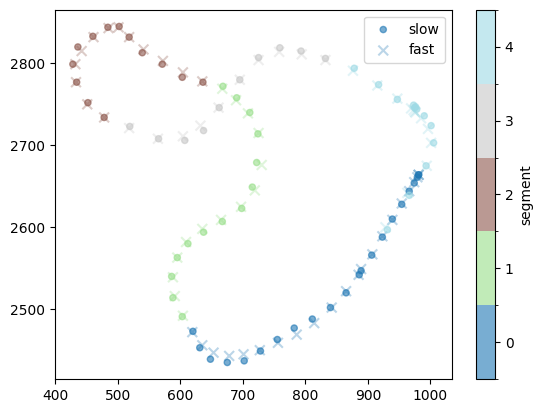

In [51]:
# Extract values from tuples - position_x and position_z contain tuples after matching
x_slow = np.array([val[0] if isinstance(val, tuple) else val for val in df_slow["position_x"]])
z_slow = np.array([val[0] if isinstance(val, tuple) else val for val in df_slow["position_z"]])
x_fast = np.array([val[1] if isinstance(val, tuple) else val for val in df_slow["position_x"]])
z_fast = np.array([val[1] if isinstance(val, tuple) else val for val in df_slow["position_z"]])

seg = df_slow["segment"].to_numpy()

unique = np.unique(seg)
cmap = plt.get_cmap("tab20", len(unique))
norm = BoundaryNorm(np.arange(len(unique)+1) - 0.5, cmap.N)

mapping = {val: i for i, val in enumerate(unique)}
seg_mapped = np.array([mapping[v] for v in seg])

# Plot slow (original) values
sc_slow = plt.scatter(x_slow, z_slow, c=seg_mapped, cmap=cmap, norm=norm, s=20, zorder=5, alpha=0.6, label='slow')
# Plot fast (matched) values in different style
plt.scatter(x_fast, z_fast, c=seg_mapped, cmap=cmap, norm=norm, s=50, zorder=4, alpha=0.3, marker='x', label='fast')

cbar = plt.colorbar(sc_slow, ticks=np.arange(len(unique)))
cbar.ax.set_yticklabels(unique)
cbar.set_label("segment")

plt.legend()
plt.show()

In [52]:
# Add units to header columns
df_slow = df_slow.rename(columns={
    'timestamp': 'timestamp in s',
    'acceleration_x': 'acceleration_x in m/s²',
    'acceleration_y': 'acceleration_y in m/s²',
    'acceleration_z': 'acceleration_z in m/s²',
    'yaw': 'yaw in degrees',
    'position_x': 'position_x in m',
    'position_y': 'position_y in m',
    'position_z': 'position_z in m',
    'speed': 'speed in km/h',
    })

df_slow

,timestamp in s,acceleration_x in m/s²,acceleration_y in m/s²,acceleration_z in m/s²,yaw in degrees,position_x in m,position_y in m,position_z in m,speed in km/h,lap_number,segment
0,"(0.0, 0.0)","(0, 0)","(0, 0)","(0, 0)","(-2.5, -2.5)","(981, 981)","(303, 303)","(2664, 2664)","(0, 0)",0,0
19,"(0.983, 0.052)","(0, 0)","(0, 0)","(2, 0)","(-2.5, -2.5)","(981, 981)","(303, 303)","(2664, 2664)","(1, 0)",0,0
38,"(1.99, 0.828)","(0, 0)","(0, 0)","(7, 13)","(-2.5, -2.5)","(979, 979)","(303, 303)","(2661, 2661)","(23, 32)",0,0
57,"(2.981, 1.408)","(0, 0)","(0, 0)","(5, 16)","(-2.49, -2.5)","(974, 974)","(302, 302)","(2654, 2655)","(38, 63)",0,0
76,"(3.992, 2.038)","(0, 0)","(0, 0)","(5, 16)","(-2.48, -2.49)","(966, 966)","(301, 302)","(2644, 2644)","(58, 96)",0,0
...,...,...,...,...,...,...,...,...,...,...,...
1273,"(68.754, 45.815)","(12, 21)","(0, 1)","(9, -2)","(-2.6, 3.1)","(1005, 1001)","(305, 305)","(2703, 2703)","(86, 92)",0,4
1292,"(69.815, 46.864)","(5, 8)","(-2, -5)","(11, 5)","(-2.5, -2.5)","(993, 994)","(304, 304)","(2675, 2675)","(125, 117)",0,4
1311,"(70.868, 48.061)","(4, -10)","(-1, 0)","(4, 12)","(-2.45, -2.36)","(966, 963)","(301, 301)","(2639, 2642)","(173, 162)",0,4
1330,"(71.929, 49.18)","(0, -6)","(1, 0)","(9, 9)","(-2.44, -2.53)","(931, 928)","(298, 298)","(2597, 2600)","(209, 187)",0,4


In [53]:
# Try markdown format
markdown = df_slow.to_markdown()
with open(MD, 'w', encoding="utf-8") as f:
    f.write(markdown)

In [54]:
# Write output.txt
records = df_slow.to_dict(orient="records")
text = str(records)
for char in '[]{}()':
    text = text.replace(char, '')
    
text = text.replace('timestamp', '\ntimestamp')

with open(OUTPUT, "w", encoding="utf-8") as f:
    f.write(text)